In [1]:
!pip install yfinance


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [2]:
import yfinance as yf

In [3]:
data = yf.download("^NSEI", start="2020-01-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
data.head(10)

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2020-01-01,12182.500000,12222.200195,12165.299805,12202.150391,304100
2020-01-02,12282.200195,12289.900391,12195.250000,12198.549805,407700
2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800
2020-01-06,11993.049805,12179.099609,11974.200195,12170.599609,396500
2020-01-07,12052.950195,12152.150391,12005.349609,12079.099609,447800
2020-01-08,12025.349609,12044.950195,11929.599609,11939.099609,446000
2020-01-09,12215.900391,12224.049805,12132.549805,12153.150391,477500
2020-01-10,12256.799805,12311.200195,12213.200195,12271.000000,660600


In [5]:
data.columns

MultiIndex([( 'Close', '^NSEI'),
            (  'High', '^NSEI'),
            (   'Low', '^NSEI'),
            (  'Open', '^NSEI'),
            ('Volume', '^NSEI')],
           names=['Price', 'Ticker'])

In [6]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


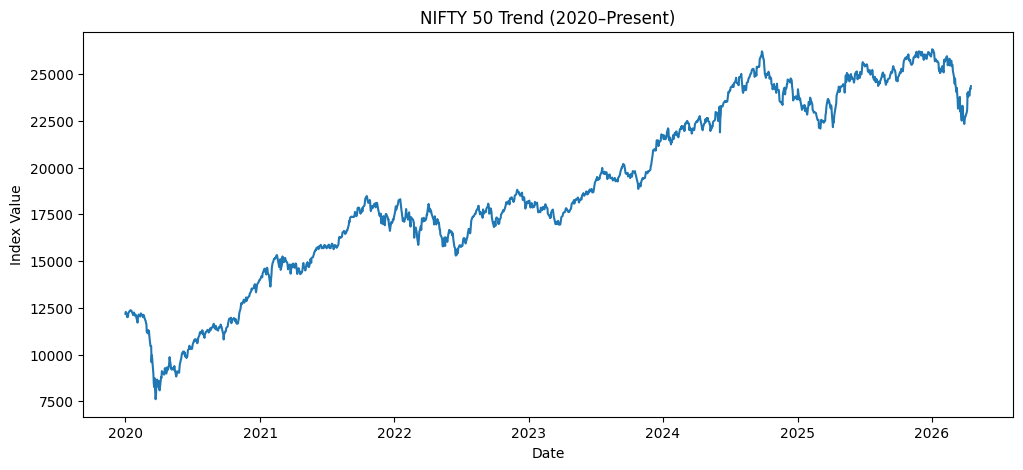

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title("NIFTY 50 Trend (2020–Present)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()

In [8]:
#Run in command shell
# py -3.11 -m pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


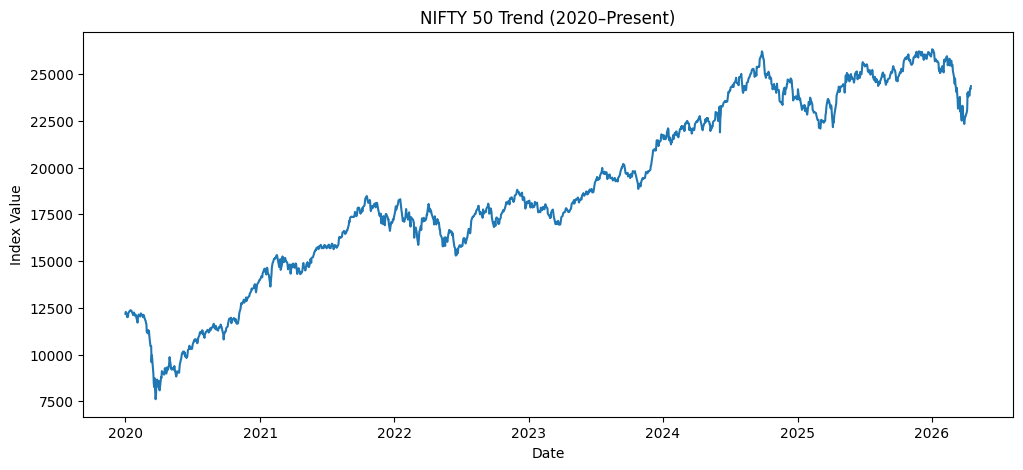

In [9]:
!pip install matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title("NIFTY 50 Trend (2020–Present)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()

Daily Returns Calculated and populated in data['Returs']

Intuition first (very important)

Stock prices themselves are not comparable over time.

Example:

NIFTY at 8000 → moves to 8200 → +200
NIFTY at 18000 → moves to 18200 → +200

👉 Same change (200), but impact is different

First = +2.5%
Second = +1.1%

👉 So markets are analyzed in percentage change, not raw price.

What pct_change() actually does: 

It computes:

Return_t = (𝑃_t - P_t-1)/ P_t-1

P_t = today’s closing price
P_t-1 = yesterday’s closing price

| Day   | Close | Return                             |
| ----- | ----- | ---------------------------------- |
| Day 1 | 100   | —                                  |
| Day 2 | 110   | (110-100)/100 = **0.10 (10%)**     |
| Day 3 | 105   | (105-110)/110 = **-0.045 (-4.5%)** |

Why this matters (deep insight)

Returns give you:

✔ Direction (up/down)
✔ Magnitude (how strong)
✔ Comparability across time
✔ Stationarity (important for ML models)

👉 Most financial models never use raw price, only returns.


In [10]:
data['Returns'] = data['Close'].pct_change()

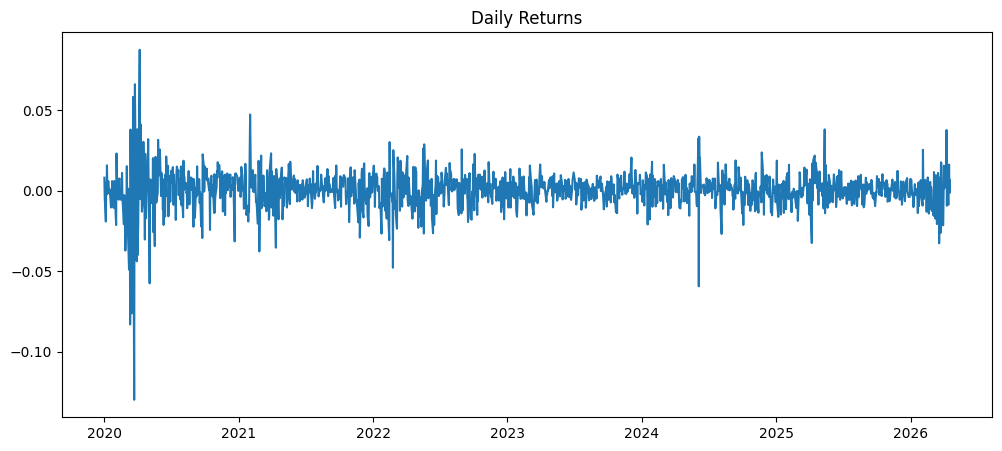

In [11]:
plt.figure(figsize=(12,5))
plt.plot(data['Returns'])
plt.title("Daily Returns")
plt.show()

Your data dataframe contains:

Open
High
Low
Close
Adj Close
Volume

Intuition first

Volatility = “how unpredictable / jumpy the market is”

Calm market → small daily changes
Chaotic market → big swings

What this formula means

We take:

👉 Last 20 days of returns
👉 Measure how spread out they are

Volatility (Standard Deviation) Formula:

sigma = sqrt( (1/n) * sum( (Ri - R_avg)^2 ) )

Where:

Ri    = daily return
R_avg = average return
n     = number of days (e.g., 20)

Why “rolling window = 20”?

👉 20 trading days ≈ 1 month

So this answers:

“How volatile has the market been in the last month?”

Example
Case 1: Stable market

Returns:

0.01, 0.02, 0.015, 0.01, 0.02

👉 Very similar → low volatility

Case 2: Chaotic market

Returns:

0.10, -0.08, 0.12, -0.09, 0.11

👉 Huge swings → high volatility

Why this matters (this is BIG)

Volatility is:

A measure of fear / uncertainty
Strongly linked to:
wars
elections
economic shocks

👉 This is EXACTLY where your geopolitics + sentiment idea fits

| Metric     | Meaning              | Why important         |
| ---------- | -------------------- | --------------------- |
| Returns    | Daily % movement     | Direction + magnitude |
| Volatility | Stability of returns | Risk / uncertainty    |

Critical insight (don’t miss this)

👉 Price tells you “where market is”
👉 Returns tell you “how it moves”
👉 Volatility tells you “how stable that movement is”



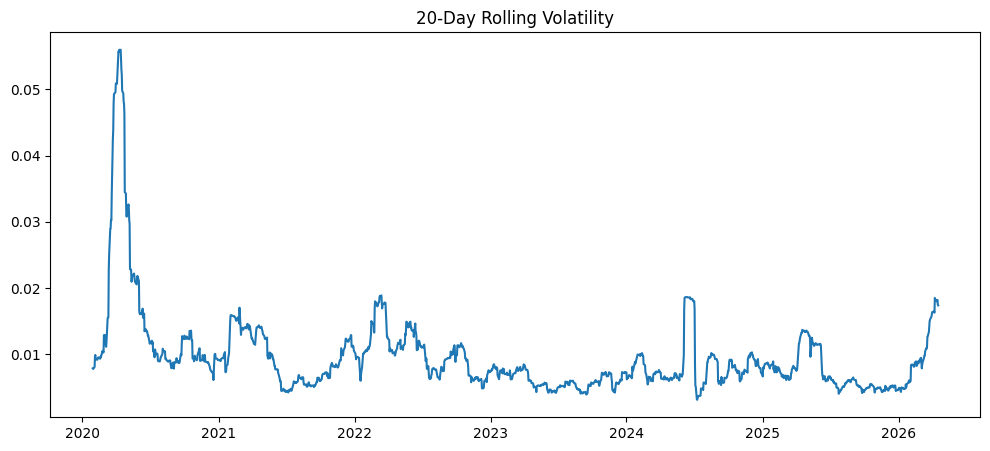

In [12]:
data['Volatility'] = data['Returns'].rolling(window=20).std()

plt.figure(figsize=(12,5))
plt.plot(data['Volatility'])
plt.title("20-Day Rolling Volatility")
plt.show()

What is a Moving Average (MA)?

A moving average smooths out price fluctuations to show the underlying trend.

Instead of looking at noisy daily prices, you ask:

“What’s the average price over the last X days?”

Moving Average Formula (MAₙ): 
MA_n = (1 / n) * Σ(i = 0 to n - 1) [ P_(t - i) ]

Or
MA_n = ( P_t + P_(t-1) + P_(t-2) + ... + P_(t-(n-1)) ) / n

P_(t - i) = past closing prices
n         = number of days (e.g., 50 or 200)
t         = current time/day
Σ         = summation (add all values from i = 0 to n - 1)





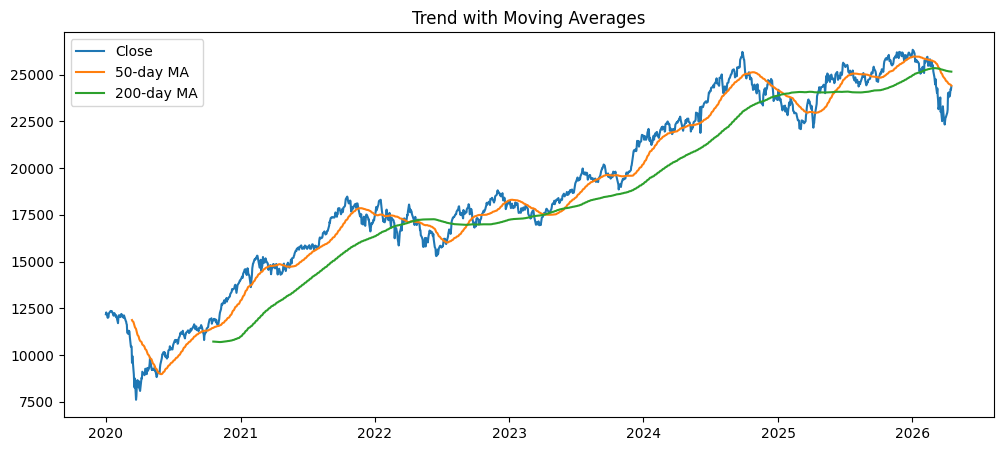

In [13]:
# For each day:
# Take last 50 days of closing prices
# Compute their average
# Assign it as MA50
data['MA50'] = data['Close'].rolling(50).mean()

data['MA200'] = data['Close'].rolling(200).mean()

# Why 50 and 200?

# These are industry-standard timeframes:
# | MA         | Meaning           |
# | ---------- | ----------------- |
# | 50-day MA  | Medium-term trend |
# | 200-day MA | Long-term trend   |

# Intuition (this is the key)

# Think of it like this:

# Price = daily mood swings
# MA50 = recent behavior
# MA200 = long-term personality

plt.figure(figsize=(12,5))
plt.plot(data['Close'], label='Close')
plt.plot(data['MA50'], label='50-day MA')
plt.plot(data['MA200'], label='200-day MA')
plt.legend()
plt.title("Trend with Moving Averages")
plt.show()

# You’ll see:

# Price zig-zagging
# MA50 smoother
# MA200 very smooth (slow-moving)


👉 Moving averages help detect phase transitions


Creating lag features

🧠 What are we trying to do here?

We want to answer:

“Can past market behavior help predict what happens next?”

So we:

Use past data → inputs (features)
Predict future outcome → target

In [14]:
data['Lag1'] = data['Returns'].shift(1)
data['Lag2'] = data['Returns'].shift(2)
data['Lag3'] = data['Returns'].shift(3)

What does .shift() do?

👉 It shifts data down by N rows

So:

shift(1) = yesterday’s value
shift(2) = day before yesterday
shift(3) = 3 days ago

Example (very important)
| Date  | Returns | Lag1  | Lag2  | Lag3 |
| ----- | ------- | ----- | ----- | ---- |
| Day 1 | 0.02    | —     | —     | —    |
| Day 2 | -0.01   | 0.02  | —     | —    |
| Day 3 | 0.03    | -0.01 | 0.02  | —    |
| Day 4 | 0.01    | 0.03  | -0.01 | 0.02 |

On Day 4, your model sees:

Yesterday = 0.03  
2 days ago = -0.01  
3 days ago = 0.02  

Why do we do this?

Because:

👉 ML models cannot understand time automatically

You must explicitly tell them:

“Here is the recent history”

So lag features = memory of the system


In [15]:
# Remove missing values
data = data.dropna()

Why NaNs appear?

Because:

First row has no Lag1
First 2 rows have no Lag2
First 3 rows have no Lag3

👉 These become NaN (empty values)

Why drop them?

ML models cannot train on missing values.

In [16]:
# Define the target (what we predict)

data['Target'] = (data['Returns'] > 0).astype(int)

# If return > 0 → 1  
# If return <= 0 → 0  

# Example
# | Returns | Target |
# | ------- | ------ |
# | 0.02    | 1      |
# | -0.01   | 0      |
# | 0.00    | 0      |
# | 0.03    | 1      |

# Why convert to 0 and 1?

# Because now this becomes a:

# 👉 Classification problem

# Instead of predicting exact value, we ask:

# “Will market go UP or DOWN?”




Putting it all together

Now your dataset looks like:

| Lag1  | Lag2  | Lag3  | Target |
| ----- | ----- | ----- | ------ |
| 0.03  | -0.01 | 0.02  | 1      |
| -0.02 | 0.03  | -0.01 | 0      |
| 0.01  | -0.02 | 0.03  | 1      |

🧠 What the model learns

It tries to learn patterns like:

“If last 3 days were positive → next day likely positive”
“If high volatility pattern → next move uncertain”
“If mixed pattern → reversal possible”

Critical insight (this is where most beginners fail)

👉 You are NOT predicting price
👉 You are predicting direction

Important limitation (very important)

This model currently uses:

👉 ONLY past returns

It ignores:

News
Sentiment
Global events

Where your idea becomes powerful

You will extend this to:

Lag1	Lag2	Lag3	Sentiment	Volatility	Target

👉 Now model sees market + human emotion

Final mental model

Think of it like this:

Lag features = memory
Target = decision
Model = pattern recognizer

In [17]:
!pip install sklearn
!pip install scikit-learn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [18]:
X = data[['Lag1', 'Lag2', 'Lag3']]
y = data['Target']

In [19]:
import sys
print(sys.executable)

c:\Users\Rituparna\AppData\Local\Programs\Python\Python311\python.exe


In [20]:
# Train-test split (VERY important)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

Train a simple model

Why Logistic Regression?
Simple
Interpretable
Good baseline

👉 You’re predicting 0 or 1 → classification

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
#Make predictions
predictions = model.predict(X_test)

In [23]:
#Evaluate performance
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.5330882352941176


In [24]:
#Confusion matrix (deep insight)
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, predictions))

[[  0 127]
 [  0 145]]


🧠 What a confusion matrix is
It shows how your model’s predictions compare to reality.

                Predicted
              0         1
Actual  0    TN        FP
        1    FN        TP

| Term                    | Meaning                           |
| ----------------------- | --------------------------------- |
| **TP (True Positive)**  | Predicted UP, actually UP ✅       |
| **TN (True Negative)**  | Predicted DOWN, actually DOWN ✅   |
| **FP (False Positive)** | Predicted UP, but actually DOWN ❌ |
| **FN (False Negative)** | Predicted DOWN, but actually UP ❌ |


🧠 This tells you:
How many ups predicted correctly
How many downs predicted correctly

What you just built

👉 Your first market prediction model

Using:

Past returns (memory)
Binary direction (target)

Honest truth (important for you)

This model is:

✅ Good starting point
❌ Not powerful yet

Because it uses ONLY price history.

🧠 What this means (very clearly)
👉 Your model is predicting:
LWAYS → 1 (market will go UP)

It never predicts 0 (DOWN)

Breakdown
| Metric   | Value | Meaning                            |
| -------- | ----- | ---------------------------------- |
| TN = 0   | ❌     | Never correctly predicts DOWN      |
| FP = 126 | ❌     | Predicts UP when it should be DOWN |
| FN = 0   | ⚠️    | Never predicts DOWN                |
| TP = 145 | ✅     | Correct when market goes UP        |


Critical insight

👉 Your model has learned only this:

"Market usually goes UP → always predict UP"
Why you still got ~53% accuracy

Because:

Market is slightly upward biased
So predicting “UP always” gives ~53% accuracy

👉 Your model is basically doing:
always_predict = 1

⚠️ This is NOT a real model

It’s a naive strategy disguised as ML

Why this happened

Most likely reasons:

1. Weak features

You only used:

Lag1, Lag2, Lag3

👉 Not enough signal to distinguish UP vs DOWN

2. Class imbalance (likely)

Market goes up slightly more than down → model exploits that

3. Logistic regression default behavior

It minimizes error → easiest solution:

Predict majority class


In [25]:
#Check Class Balance

print(y.value_counts(normalize=True))

Target
1    0.544584
0    0.455416
Name: proportion, dtype: float64


If output is like:

1 → 0.53  
0 → 0.47

👉 Then your model might just be predicting “UP” most of the time

🚀 Now the real work begins

We need to force the model to think better

In [26]:
#Add better features (MOST IMPORTANT)
X = data[['Lag1', 'Lag2', 'Lag3', 'Volatility']]
data['Trend'] = (data['MA50'] > data['MA200']).astype(int)
X['Trend'] = data['Trend']


In [27]:
#Handle imbalance
model = LogisticRegression(class_weight='balanced')

In [28]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

class_weight='balanced' is used in many models from scikit-learn to handle imbalanced datasets.
The problem it solves

Imagine your target data:

90% → Class 0 (market down)
10% → Class 1 (market up)

A model can easily get 90% accuracy by always predicting 0 😑
…but it completely ignores the minority class.

What class_weight='balanced' does

It automatically assigns higher importance (weight) to the minority class.
Weight = total samples / (number of classes * samples in the class)

Intuition (simple)
Rare class → more penalty if wrong
Common class → less penalty

So the model is forced to pay attention to both classes.

Without weights:

Class 0 → weight = 1
Class 1 → weight = 1

With balanced:

Class 0 (90 samples) → weight ≈ 0.56
Class 1 (10 samples) → weight ≈ 5.0

👉 Misclassifying Class 1 is now ~9× more costly

In [29]:
import numpy as np
print(np.unique(predictions, return_counts=True))

(array([1]), array([272]))


In [30]:
#Confusion matrix (deep insight)
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, predictions))

[[  0 127]
 [  0 145]]


In [31]:
X = data[['Lag1', 'Lag2', 'Lag3', 'Volatility', 'Trend']]
y = data['Target']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [33]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [34]:
predictions = model.predict(X_test)

In [35]:
import numpy as np
print(np.unique(predictions, return_counts=True))

(array([0, 1]), array([ 89, 183]))


Why this will work

Decision Tree:

Can capture non-linear patterns
Doesn’t assume linear relationships
More flexible than logistic regression

Important realization (this is big)

You just discovered:

👉 “Simple models + weak features → trivial predictions”

This is EXACTLY why most ML projects fail.



In [36]:
# Predictions
predictions = model.predict(X_test)

# 1. Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

# 2. Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print("\nConfusion Matrix:")
print(cm)

# Optional: labeled confusion matrix (more readable)
import pandas as pd
cm_df = pd.DataFrame(
    cm,
    index=['Actual Down (0)', 'Actual Up (1)'],
    columns=['Predicted Down (0)', 'Predicted Up (1)']
)
print("\nLabeled Confusion Matrix:")
print(cm_df)

# 3. Prediction Distribution
import numpy as np
values, counts = np.unique(predictions, return_counts=True)

print("\nPrediction Distribution:")
for v, c in zip(values, counts):
    label = "Down (0)" if v == 0 else "Up (1)"
    print(f"{label}: {c}")

Accuracy: 0.5367647058823529

Confusion Matrix:
[[ 45  82]
 [ 44 101]]

Labeled Confusion Matrix:
                 Predicted Down (0)  Predicted Up (1)
Actual Down (0)                  45                82
Actual Up (1)                    44               101

Prediction Distribution:
Down (0): 89
Up (1): 183


👉 Decision Tree worked better because your data is non-linear and rule-based, while Logistic Regression assumes a simple linear boundary.

A Decision Tree works like:
If Lag1 > 0:
    If Volatility < 0.02 → UP
    Else → DOWN
Else:
    If Trend == 1 → UP
    Else → DOWN

Why Decision Tree worked better for YOU
✅ Reason 1: Market behavior is conditional

Markets behave like:

If recent returns positive → continue trend
If high volatility → reversal likely
If bearish trend → downward bias

👉 These are IF-ELSE patterns, not linear relationships

✅ Reason 2: Feature interactions

Example:

Lag1 alone → weak signal
Lag1 + Volatility together → strong signal

👉 Decision Tree captures this naturally
👉 Logistic Regression struggles unless explicitly engineered

✅ Reason 3: Non-linearity

Market patterns are:

asymmetric
noisy
regime-based

👉 Decision Tree handles this
👉 Logistic Regression assumes smooth linearity

✅ Reason 4: Class imbalance handling

Logistic Regression earlier:

👉 Took shortcut → “always UP”

Decision Tree:

👉 Forced to split data → makes real decisions

Core insight (this is the real takeaway)

👉 Your problem is NOT:

linear prediction problem

👉 It is:

pattern + condition + regime problem

⚠️ But be careful

Decision Trees can:

Overfit easily
Memorize noise

That’s why you used:

max_depth=5

👉 Good instinct

🚀 Where this leads next

Now you’ve discovered:

“Better model + weak features = still limited performance”

👉 So next step is NOT just better models

👉 It is:

🔥 Better FEATURES (your real edge)

Especially:

Sentiment
Geopolitical signals
Event timing

👉 ML in finance is NOT just modeling
👉 It is time-aware modeling

Add Sentiment


In [47]:
#Saving the model 
!pip install joblib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [48]:
import joblib
joblib.dump(model, "stock_model.pkl")

['stock_model.pkl']

In [53]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib

# Download latest data
df = yf.download("^NSEI", period="3mo", interval="1d")

# Features
df["Returns"] = df["Close"].pct_change()
df["MA5"] = df["Close"].rolling(5).mean()
df["MA10"] = df["Close"].rolling(10).mean()

df["Lag1"] = df["Returns"].shift(1)
df["Lag2"] = df["Returns"].shift(2)
df["Lag3"] = df["Returns"].shift(3)

df.dropna(inplace=True)

# EXACT 5 features
latest = df[["MA5","MA10","Lag1","Lag2","Lag3"]].tail(1)

# Predict
pred = model.predict(latest)[0]

print("Prediction for next session:")
print("UP" if pred == 1 else "DOWN")

[*********************100%***********************]  1 of 1 completed

Prediction for next session:
DOWN


In [54]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib

# Load trained model
model = joblib.load("stock_model.pkl")

# Download recent NIFTY data
df = yf.download("^NSEI", period="3mo", interval="1d")

# Daily returns
df["Returns"] = df["Close"].pct_change()

# Same features as training
df["Lag1"] = df["Returns"].shift(1)
df["Lag2"] = df["Returns"].shift(2)
df["Lag3"] = df["Returns"].shift(3)

df["Volatility"] = df["Returns"].rolling(5).std()

# Trend (estimated from your likely logic)
df["Trend"] = np.where(df["Close"] > df["Close"].rolling(5).mean(), 1, 0)

# Clean rows
df.dropna(inplace=True)

# Latest row = today's completed market data
latest = df[["Lag1", "Lag2", "Lag3", "Volatility", "Trend"]].tail(1)

# Predict tomorrow
pred = model.predict(latest)[0]
prob = model.predict_proba(latest)[0]

print("Prediction for Tomorrow:")

if pred == 1:
    print("UP 📈")
else:
    print("DOWN 📉")

print("Confidence:", round(max(prob)*100,2), "%")

[*********************100%***********************]  1 of 1 completed

Prediction for Tomorrow:
UP 📈
Confidence: 55.13 %


In [55]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib

# Load model
model = joblib.load("stock_model.pkl")

# Download data
df = yf.download("^NSEI", period="3mo", interval="1d")

# Features
df["Returns"] = df["Close"].pct_change()

df["Lag1"] = df["Returns"].shift(1)
df["Lag2"] = df["Returns"].shift(2)
df["Lag3"] = df["Returns"].shift(3)

df["Volatility"] = df["Returns"].rolling(5).std()

df["Trend"] = np.where(df["Close"] > df["Close"].rolling(5).mean(), 1, 0)

df.dropna(inplace=True)

# Latest feature row
latest = df[["Lag1","Lag2","Lag3","Volatility","Trend"]].tail(1)

# Prediction
pred = model.predict(latest)[0]
prob = model.predict_proba(latest)[0]

# Last market date
last_date = df.index[-1]

# Next prediction date
next_date = last_date + pd.Timedelta(days=1)

# Optional: skip weekend
while next_date.weekday() >= 5:
    next_date += pd.Timedelta(days=1)

# Output
print("Prediction for:", next_date.date())

if pred == 1:
    print("Market Direction: UP 📈")
else:
    print("Market Direction: DOWN 📉")

print("Confidence:", round(max(prob)*100,2), "%")

[*********************100%***********************]  1 of 1 completed

Prediction for: 2026-04-20
Market Direction: UP 📈
Confidence: 55.13 %
